# Start here: PyGAGE and Pathview validation

This notebook is the front page. It tells you what was tested and where to go next.

You do **not** need to know R or Python before reading it. The detailed notebooks explain each table, each code block, and each output.

In [1]:
from pathlib import Path
import json
import os
import sys

ROOT = Path.cwd().resolve()
if ROOT.name in {"notebooks", "executed"}:
    ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT.parents[1]

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))
print("Validation folder:", ROOT)

Validation folder: /Users/summermalik/Desktop/PATHVIEW-MARKDOWN/pygage-pathview-validation


## The short answer

- PyGAGE's classical paired analysis runs on the new repository data and matches the packaged R GAGE reference numbers.
- Python Pathview Plus produces a normal one-color node when there is one condition.
- With two conditions, both R pathview and Python Pathview Plus put the **first condition on the left** and the **second condition on the right**.
- The controlled test uses `Classical = -2` and `Basal = +2`, so the expected node is green on the left and red on the right.

In [2]:
import polars as pl

def count_status(path):
    report = json.loads(path.read_text())
    statuses = [item["status"] for item in report["checks"]]
    return {
        "component": report["component"],
        "passed": statuses.count("pass"),
        "failed": statuses.count("fail"),
        "not_run": statuses.count("not_run"),
    }

summary = pl.DataFrame([
    count_status(ROOT / "results" / "pygage" / "validation.json"),
    count_status(ROOT / "results" / "pathview_python" / "validation.json"),
    count_status(ROOT / "results" / "pathview_r" / "validation.json"),
])
summary

component,passed,failed,not_run
str,i64,i64,i64
"""PyGAGE""",5,1,0
"""Pathview Plus""",7,0,5
"""R pathview""",7,0,0


`not_run` means the test needs a fresh live KEGG download. The reproducible offline tests use the official KEGG files bundled with Bioconductor R pathview, so the most important single-state and half-and-half comparisons still run completely.

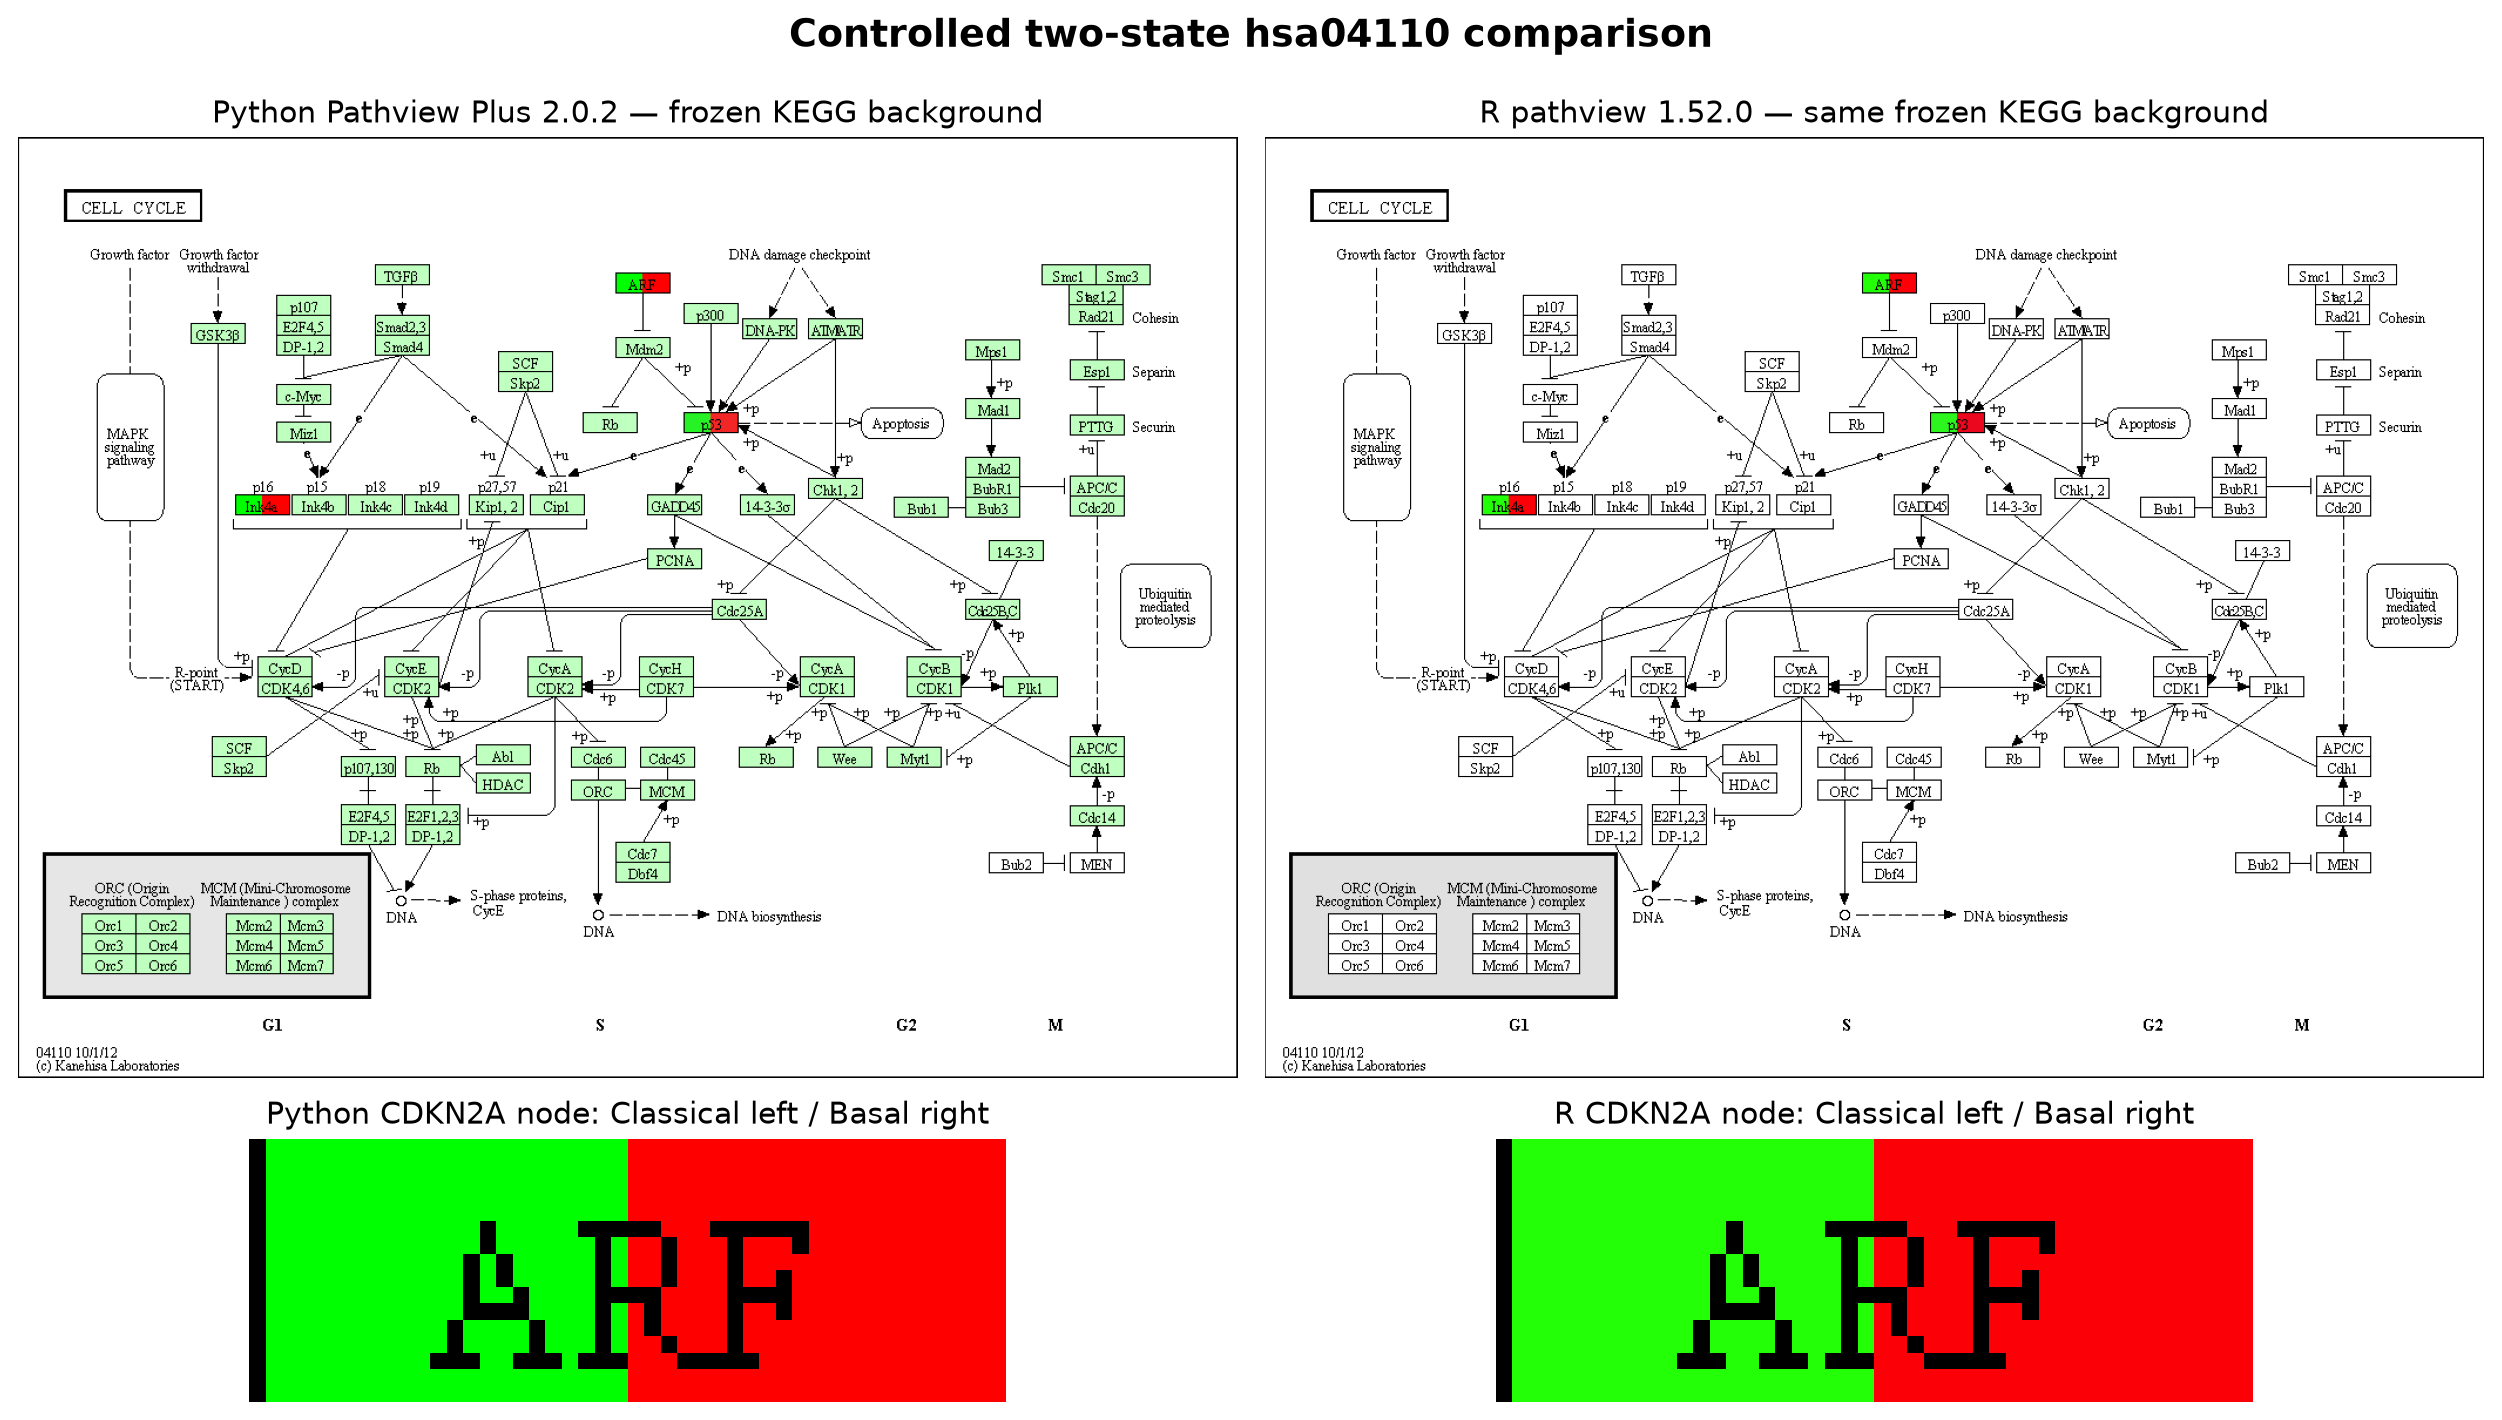

In [3]:
from IPython.display import Image, display

comparison_figure = ROOT / "results" / "comparison" / "r_vs_python_half_half.png"
display(Image(filename=str(comparison_figure), width=1100))

## Open these next

1. [01 — PyGAGE full validation](01_pygage_full_validation.ipynb)
2. [02 — Pathview Plus full validation](02_pathview_plus_full_validation.ipynb)
3. [03 — R pathview versus Python Pathview Plus](03_r_vs_python_pathview.ipynb)

The complete written conclusion is in [`reports/FULL_VALIDATION_REPORT.md`](../reports/FULL_VALIDATION_REPORT.md).